<a href="https://colab.research.google.com/github/brandy99swords/AIML2003_NLP/blob/main/week4%20/%20Lab3_CombinedEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 3 Combined Embeddings

## Cell 1: Setup

In [1]:
pip install -q sentence-transformers

In [2]:
import numpy as np # Library for numerical operations
import matplotlib.pyplot as plt # Library for plotting and visualization
from sklearn.metrics.pairwise import cosine_similarity # Scikit-learn for calculating cosine similarity
from sklearn.manifold import TSNE # Scikit-learn for dimensionality reduction (t-SNE)
from sklearn.feature_extraction.text import TfidfVectorizer # Scikit-learn for TF-IDF text feature extraction
from skimage.feature import hog # Scikit-image for Histogram of Oriented Gradients (HOG) feature extraction
from skimage.color import rgb2gray # Scikit-image for converting images to grayscale
from skimage import transform # Scikit-image for image transformations
import tensorflow as tf # Deep learning framework
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input # Keras (part of TensorFlow) for MobileNetV2 preprocessing
from collections import Counter, defaultdict # Python's standard 'collections' module for specialized container datatypes
import json # Python's standard 'json' module for JSON data handling

# Import SentenceTransformer after installation
from sentence_transformers import SentenceTransformer # Library for generating sentence embeddings

# Load text embedding model
text_model = SentenceTransformer('all-MiniLM-L6-v2') # Sentence Transformers library

# Load image feature extraction model
# include_top=False removes the classification head
# weights='imagenet' loads parameters trained on 1.2 million ImageNet images
# pooling='avg' collapses spatial dimensions (height and width) into a single vector via average pooling
# input_shape=(224, 224, 3) expects 224x224 RGB images
image_model = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet', pooling='avg', input_shape=(224, 224, 3)) # Keras (part of TensorFlow) MobileNetV2 model

# Print model names and output dimensions
print(f"Text Model: {'all-MiniLM-L6-v2'}, Output Dimension: {text_model.get_sentence_embedding_dimension()}") # Sentence Transformers library
print(f"Image Model: {'MobileNetV2'}, Output Dimension: {image_model.output_shape[1]}") # TensorFlow/Keras
print("Despite very different input formats (text vs. image), both produce fixed-length numeric vectors where cosine similarity measures 'closeness'.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Text Model: all-MiniLM-L6-v2, Output Dimension: 384
Image Model: MobileNetV2, Output Dimension: 1280
Despite very different input formats (text vs. image), both produce fixed-length numeric vectors where cosine similarity measures 'closeness'.


**Notes on embeddings.position_ids | UNEXPECTED**
  
When SentenceTransformer loads a pre-trained model like 'all-MiniLM-L6-v2', it's essentially loading a model that was originally developed within the Hugging Face Transformers library. These models are highly flexible, and sometimes the configuration or specific parameter names saved with the pre-trained weights can differ slightly from the default configuration the current transformers library expects when loading a model of that type.

Specifically, embeddings.position_ids relates to how the model handles positional information for the tokens in a sentence. The warning indicates that a position_ids parameter was found in the saved model's state dictionary but is not directly mapped or is unexpected by the current model's architecture definition when loaded in a certain way. This doesn't mean the model is incapable of performing its intended task (generating sentence embeddings). Instead, it means there's a minor mismatch in how a particular internal component's state was saved and how the library is trying to load it, often due to:

Version differences: Slight changes in library versions between when the model was saved and when it's being loaded.
Default configuration: The base model might have a default position_ids registration that differs from the specific SentenceTransformer wrapper's expectation, even if the underlying weights for the important parts of the model (like the attention layers) are perfectly fine.
In our case, the model is still loading correctly and is performing its intended task of generating accurate sentence embeddings. The core functionality is not compromised, and the all-MiniLM-L6-v2 model is being used for the task it was designed for. You can proceed with confidence that the model is working as expected for generating sentence embeddings.

## Cell 2: Load text dataset

In [3]:
from collections import Counter # Python's standard 'collections' module for counting hashable objects

# Define the four main category names
text_cat_names = ['technology', 'sports', 'cooking', 'travel']

# Define texts and their categories (15 per category)
texts = [
    # Technology (15)
    "The new AI model can generate realistic images from text descriptions.",
    "Quantum computing is a rapidly developing field with potential to revolutionize computation.",
    "Blockchain technology offers decentralized and secure record-keeping.",
    "Machine learning algorithms are used in various applications, from recommendation systems to medical diagnosis.",
    "Software engineers are always looking for efficient coding practices.",
    "Cybersecurity experts protect networks and data from malicious attacks.",
    "Virtual reality headsets provide immersive gaming and training experiences.",
    "Cloud computing services offer scalable and flexible infrastructure solutions.",
    "Data scientists analyze large datasets to extract insights and patterns.",
    "Robotics is advancing rapidly, leading to automated manufacturing and exploration.",
    "The internet of things connects devices, allowing them to collect and exchange data.",
    "Neural networks are inspired by the human brain and used in deep learning.",
    "Programming languages like Python and Java are essential for software development.",
    "Big data analytics helps businesses make informed decisions.",
    "Artificial intelligence is transforming many industries.",

    # Sports (15)
    "The football team scored a last-minute goal to win the championship.",
    "Basketball players train rigorously to improve their shooting and dribbling skills.",
    "Olympic athletes compete in various disciplines, pushing human limits.",
    "Swimming is a great full-body workout and a popular recreational activity.",
    "Tennis matches can be long and intense, requiring both physical and mental endurance.",
    "Running a marathon requires extensive training and stamina.",
    "Gymnastics demands incredible strength, flexibility, and balance.",
    "Baseball pitchers aim for precision and speed to strike out batters.",
    "Soccer is the most popular sport globally, enjoyed by millions.",
    "Volleyball teams work together to set up powerful spikes.",
    "Golfers aim for accuracy and distance on the course.",
    "Cycling offers both a competitive sport and a leisurely way to exercise.",
    "Boxing requires quick reflexes and powerful punches.",
    "Skiing down snowy mountains is an exhilarating winter sport.",
    "Surfing catches waves and rides them to the shore.",

    # Cooking (15)
    "Baking a delicious chocolate cake requires precise measurements and timing.",
    "Sautéing vegetables quickly cooks them while retaining their crunch.",
    "Grilling steak to perfection involves high heat and careful turning.",
    "Making pasta from scratch is a rewarding culinary experience.",
    "Roasting chicken until golden brown creates a flavorful and tender meal.",
    "Chopping onions without tears is a skill every cook masters.",
    "Spices add depth and complexity to many international dishes.",
    "Whipping cream to stiff peaks creates a light and airy topping.",
    "Boiling water is the first step for many cooking methods.",
    "Marinating meat infuses it with flavor before cooking.",
    "Frying eggs to a runny yolk is a breakfast favorite.",
    "Kneading dough develops gluten for chewy bread.",
    "Simmering soup for hours develops rich flavors.",
    "Peeling potatoes is often a tedious but necessary task.",
    "Seasoning food properly elevates its taste.",

    # Travel (15)
    "Exploring ancient ruins in Rome offers a glimpse into history.",
    "Hiking through national parks provides breathtaking views of nature.",
    "Relaxing on a pristine beach in the Caribbean is a perfect getaway.",
    "Visiting museums in Paris immerses you in art and culture.",
    "Safari in Africa offers encounters with diverse wildlife.",
    "Cruising along the Norwegian fjords reveals stunning landscapes.",
    "Backpacking through Southeast Asia is an adventurous journey.",
    "Discovering hidden gems in Kyoto's temples and gardens.",
    "Road tripping across America showcases diverse scenery.",
    "Sampling local cuisine in Mexico City is a delicious experience.",
    "Scuba diving in the Great Barrier Reef reveals vibrant marine life.",
    "Taking a scenic train ride through the Swiss Alps.",
    "Exploring bustling markets in Marrakech is a feast for the senses.",
    "Camping under the stars in the desert provides tranquility.",
    "Visiting historical castles in Scotland is enchanting."
]

text_categories = (
    ['technology'] * 15 +
    ['sports'] * 15 +
    ['cooking'] * 15 +
    ['travel'] * 15
)

# Define edge cases
edge_texts = [
    "I streamed the football game on my new smart TV.",
    "The robot chef perfectly baked the sourdough bread.",
    "My hiking boots broke after I cooked dinner on the trail.",
    "Artificial intelligence is now designing new recipes.",
    "The travel vlog showed how to cook local dishes."
]

edge_labels = [
    ['sports', 'technology'],
    ['technology', 'cooking'],
    ['travel', 'cooking'],
    ['technology', 'cooking'],
    ['travel', 'cooking']
]

# Print category counts
print("Category counts:", Counter(text_categories)) # collections.Counter

Category counts: Counter({'technology': 15, 'sports': 15, 'cooking': 15, 'travel': 15})


## Cell 3: Generate text embeddings

In [16]:
text_embeddings = text_model.encode(texts, show_progress_bar=False) # Sentence Transformers library

print(f"Shape of text_embeddings: {text_embeddings.shape}") # numpy array property
print(f"First 10 values of the first embedding: {text_embeddings[0][:10]}") # numpy array slicing

Shape of text_embeddings: (60, 384)
First 10 values of the first embedding: [-0.01934204 -0.04935205  0.01408796  0.02630266  0.04542361 -0.00011916
 -0.03869628 -0.00767521  0.0728128  -0.05894857]


## Cell 4: Text retrieval demo

In [5]:
def find_similar_text(query_idx, n=5):
    # Extract the query embedding from text_embeddings[query_idx] # numpy array indexing
    query_embedding = text_embeddings[query_idx]

    # Use cosine_similarity([query_embedding], text_embeddings) to score the query against all 60 embeddings.
    # Result is a shape (1, 60) array; flatten it to a 1D array of 60 scores.
    scores = cosine_similarity([query_embedding], text_embeddings)[0] # sklearn.metrics.pairwise.cosine_similarity

    # Set the query's own score to -1 (to exclude it from results).
    scores[query_idx] = -1 # numpy array assignment

    # Use np.argsort(scores)[::-1] to get indices sorted by score, highest first.
    top_n_indices = np.argsort(scores)[::-1][:n] # numpy.argsort for sorting array indices
    top_n_scores = scores[top_n_indices] # numpy array slicing

    # Prepare results for printing
    results = []
    query_category = text_categories[query_idx]

    for i in range(n):
        idx = top_n_indices[i]
        score = top_n_scores[i]
        text = texts[idx]
        category = text_categories[idx]
        category_match = '✅' if category == query_category else '❌'
        results.append({
            'index': idx,
            'score': score,
            'text': text,
            'category': category,
            'category_match': category_match
        })
    return query_idx, query_category, results


# Test with query_idx = 0 (a technology text)
query_idx_0, query_category_0, results_0 = find_similar_text(0, n=5)
print(f"Query Text (Index {query_idx_0}, Category: {query_category_0}): {texts[query_idx_0]}\n")
print("Top 5 Similar Texts:")
print(f"{'Match Category':<18} {'Score':<10} {'Text'}")
print(f"{'--------------':<18} {'-----':<10} {'----'}")
for r in results_0:
    print(f"{r['category_match']} {r['category']:<15} {r['score']:.4f}   {r['text']}")

print("\n" + "-"*80 + "\n")

# Test with query_idx = 30 (a cooking text)
query_idx_30, query_category_30, results_30 = find_similar_text(30, n=5)
print(f"Query Text (Index {query_idx_30}, Category: {query_category_30}): {texts[query_idx_30]}\n")
print("Top 5 Similar Texts:")
print(f"{'Match Category':<18} {'Score':<10} {'Text'}")
print(f"{'--------------':<18} {'-----':<10} {'----'}")
for r in results_30:
    print(f"{r['category_match']} {r['category']:<15} {r['score']:.4f}   {r['text']}")

Query Text (Index 0, Category: technology): The new AI model can generate realistic images from text descriptions.

Top 5 Similar Texts:
Match Category     Score      Text
--------------     -----      ----
✅ technology      0.3381   Neural networks are inspired by the human brain and used in deep learning.
✅ technology      0.2989   Artificial intelligence is transforming many industries.
✅ technology      0.2158   Machine learning algorithms are used in various applications, from recommendation systems to medical diagnosis.
✅ technology      0.2154   Robotics is advancing rapidly, leading to automated manufacturing and exploration.
❌ sports          0.2131   Basketball players train rigorously to improve their shooting and dribbling skills.

--------------------------------------------------------------------------------

Query Text (Index 30, Category: cooking): Baking a delicious chocolate cake requires precise measurements and timing.

Top 5 Similar Texts:
Match Category     Score

## Cell 5: Load image dataset

Loaded 150 images.
Shape of images: (150, 32, 32, 3)
Example img_labels (first 30): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Example img_names (first 30): ['airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'airplane', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile', 'automobile']
Selected CIFAR indices for highlight: [0, 1, 3, 5]


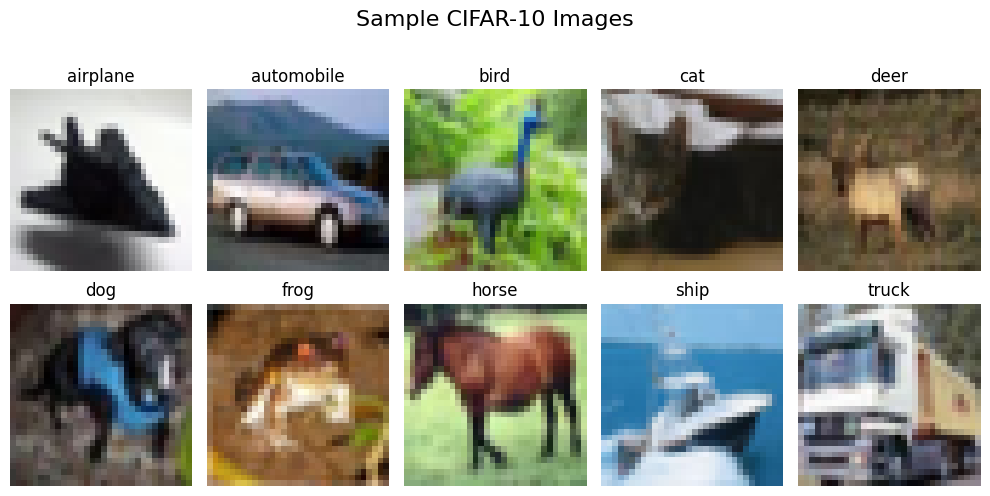

In [6]:
# Load CIFAR-10 dataset
(train_images, train_labels), _ = tf.keras.datasets.cifar10.load_data() # Keras/TensorFlow

# Define N_PER_CLASS to match the previous lab (15 images per class)
N_PER_CLASS = 15 # Python integer

# Define image class names
img_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # Python list

images = []
img_labels = []

# Select N_PER_CLASS images from each of the 10 classes
for i in range(10): # 10 classes in CIFAR-10
    # Get indices for the current class
    class_indices = np.where(train_labels.flatten() == i)[0] # numpy array method
    # Select N_PER_CLASS images for this class
    selected_images_for_class = train_images[class_indices[:N_PER_CLASS]] # numpy array slicing

    images.extend(selected_images_for_class) # Python list method
    img_labels.extend([i] * N_PER_CLASS) # Python list method

# Convert images list to a numpy array
images = np.array(images) # numpy array creation

# Define a variable for the selected CIFAR-10 classes to be highlighted in plots/demos
selected_cifar_indices = [
    img_names.index('airplane'),
    img_names.index('automobile'),
    img_names.index('cat'),
    img_names.index('dog')
] # Python list of integers

print(f"Loaded {len(images)} images.") # Python f-string
print(f"Shape of images: {images.shape}") # numpy array property
print(f"Example img_labels (first {N_PER_CLASS*2}): {img_labels[:N_PER_CLASS*2]}") # Python list slicing
print(f"Example img_names (first {N_PER_CLASS*2}): {[img_names[label] for label in img_labels[:N_PER_CLASS*2]]}") # Python list comprehension
print(f"Selected CIFAR indices for highlight: {selected_cifar_indices}") # Python f-string

# Display a sample grid of images (one from each class)
plt.figure(figsize=(10, 5)) # matplotlib.pyplot figure

for i in range(len(img_names)): # Python list length
    # Find the index of the first image for the current class
    # The images are arranged such that the first N_PER_CLASS images are of class 0, next N_PER_CLASS of class 1, etc.
    idx = i * N_PER_CLASS # Python integer arithmetic
    plt.subplot(2, 5, i + 1) # matplotlib.pyplot subplot
    plt.imshow(images[idx]) # matplotlib.pyplot imshow
    plt.title(img_names[img_labels[idx]]) # matplotlib.pyplot title
    plt.axis('off') # matplotlib.pyplot axis

plt.suptitle('Sample CIFAR-10 Images', y=1.02, fontsize=16) # matplotlib.pyplot suptitle
plt.tight_layout() # matplotlib.pyplot tight_layout
plt.show() # matplotlib.pyplot show

## Cell 6: Extract image embeddings

In [7]:
print('Resizing and preprocessing images...')

# Resize all images at once for efficiency.
# tf.image.resize expects a batch of images, so 'images' can be passed directly.
resized_images = tf.image.resize(images, (224, 224)) # tensorflow

# Preprocess pixel values for MobileNetV2
# This scales pixel values to the range expected by MobileNetV2, typically -1 to 1.
preprocessed_images = preprocess_input(resized_images) # Keras (part of TensorFlow)

# Generate embeddings for all preprocessed images
# image_model.predict() is efficient for batch processing.
image_embeddings = image_model.predict(preprocessed_images, verbose=0) # Keras (part of TensorFlow)

print('Generating image embeddings...Done!')

# Print shape, sample values, and sparsity
print(f"Shape of image_embeddings: {image_embeddings.shape}") # numpy array property
print(f"First 10 values of the first embedding: {image_embeddings[0][:10]}") # numpy array slicing

# Calculate sparsity (percentage of exact zeros)
sparsity = (image_embeddings == 0).sum() / image_embeddings.size * 100 # numpy array operation
print(f"Percentage of exact zeros (sparsity): {sparsity:.2f}%")

Resizing and preprocessing images...
Generating image embeddings...Done!
Shape of image_embeddings: (150, 1280)
First 10 values of the first embedding: [0.2388996  0.3666968  0.0848704  0.47409326 0.94851565 0.19774495
 1.4015666  0.22203039 0.         0.00393312]
Percentage of exact zeros (sparsity): 20.29%


**Display Resized Images**

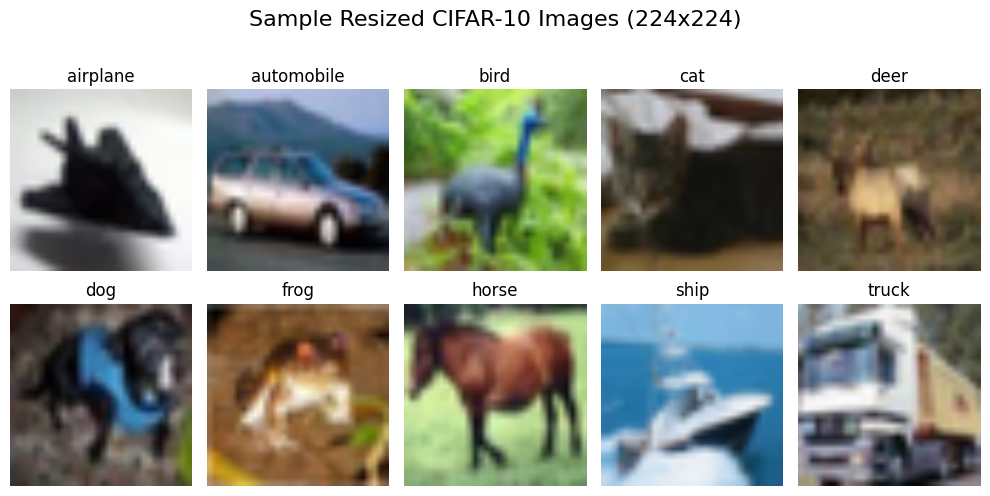

In [8]:
plt.figure(figsize=(10, 5))

# Display a sample grid of resized images (one from each class)
for i in range(len(img_names)): # Loop through each of the 10 classes
    # Find the index of the first image for the current class
    # The images are arranged such that the first N_PER_CLASS images are of class 0, next N_PER_CLASS of class 1, etc.
    idx = i * N_PER_CLASS # Python integer arithmetic
    plt.subplot(2, 5, i + 1) # Arrange in a 2x5 grid
    # Convert tensor to numpy array and ensure it's uint8 for correct display
    plt.imshow(resized_images[idx].numpy().astype('uint8')) # matplotlib.pyplot imshow
    plt.title(img_names[img_labels[idx]]) # matplotlib.pyplot title
    plt.axis('off') # matplotlib.pyplot axis

plt.suptitle('Sample Resized CIFAR-10 Images (224x224)', y=1.02, fontsize=16) # matplotlib.pyplot suptitle
plt.tight_layout() # matplotlib.pyplot tight_layout
plt.show() # matplotlib.pyplot show

## Cell 7: Image retrieval **demo**

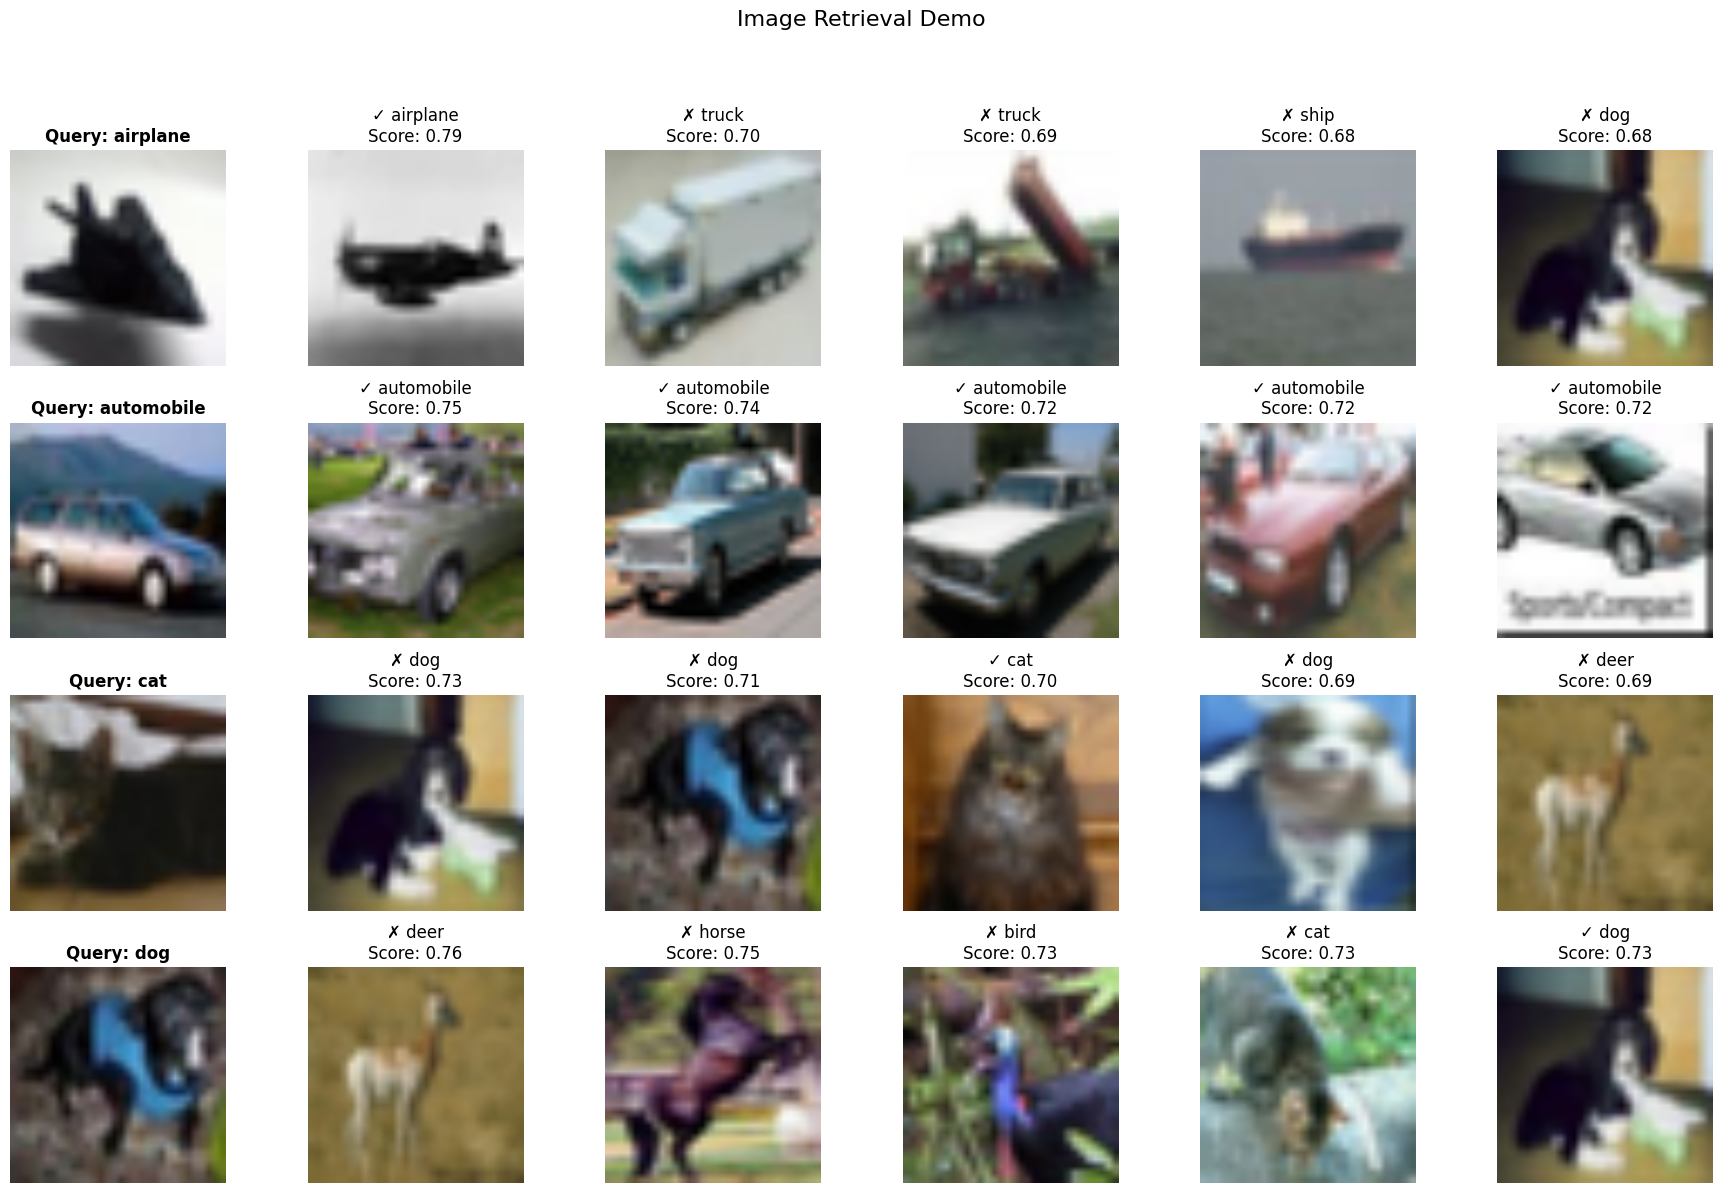

In [9]:
def find_similar_image(query_idx, n=5):
    # Extract the query embedding
    query_embedding = image_embeddings[query_idx]

    # Use cosine_similarity to score the query against all embeddings
    scores = cosine_similarity([query_embedding], image_embeddings)[0]

    # Set the query's own score to -1 to exclude it from results
    scores[query_idx] = -1

    # Get indices sorted by score, highest first
    top_n_indices = np.argsort(scores)[::-1][:n]
    top_n_scores = scores[top_n_indices]

    return top_n_indices, top_n_scores

# Modified display function to accept a row of axes
def display_similar_images(query_idx, top_indices, top_scores, n, axes_row):
    query_label = img_labels[query_idx]

    # Display query image
    axes_row[0].imshow(resized_images[query_idx].numpy().astype('uint8'))
    axes_row[0].set_title(f"Query: {img_names[query_label]}", fontweight='bold')
    axes_row[0].axis('off')

    # Display top N similar images
    for i, (idx, score) in enumerate(zip(top_indices, top_scores)):
        match_image = resized_images[idx].numpy().astype('uint8')
        match_label = img_labels[idx]

        # Determine symbol for match category
        category_match_symbol = '✓' if match_label == query_label else '✗'

        axes_row[i + 1].imshow(match_image)
        axes_row[i + 1].set_title(f"{category_match_symbol} {img_names[match_label]}\nScore: {score:.2f}")
        axes_row[i + 1].axis('off')

# --- Combine all queries into a single figure --- #
# Create a single figure with 4 rows (for 4 queries) and (n+1) columns (for query + n matches)
n = 5 # Number of similar images to display
fig, all_axes = plt.subplots(4, n + 1, figsize=(18, 12))
fig.suptitle('Image Retrieval Demo', y=1.02, fontsize=16)

# Query 1: First image of 'airplane' (index 0)
query_idx_1 = selected_cifar_indices[0] * N_PER_CLASS
top_indices_1, top_scores_1 = find_similar_image(query_idx_1, n=n)
display_similar_images(query_idx_1, top_indices_1, top_scores_1, n=n, axes_row=all_axes[0])

# Query 2: First image of 'automobile'
query_idx_2 = selected_cifar_indices[1] * N_PER_CLASS
top_indices_2, top_scores_2 = find_similar_image(query_idx_2, n=n)
display_similar_images(query_idx_2, top_indices_2, top_scores_2, n=n, axes_row=all_axes[1])

# Query 3: First image of 'cat'
query_idx_3 = selected_cifar_indices[2] * N_PER_CLASS
top_indices_3, top_scores_3 = find_similar_image(query_idx_3, n=n)
display_similar_images(query_idx_3, top_indices_3, top_scores_3, n=n, axes_row=all_axes[2])

# Query 4: First image of 'dog'
query_idx_4 = selected_cifar_indices[3] * N_PER_CLASS
top_indices_4, top_scores_4 = find_similar_image(query_idx_4, n=n)
display_similar_images(query_idx_4, top_indices_4, top_scores_4, n=n, axes_row=all_axes[3])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout for main title
plt.show()

# Remove the print separators as they are no longer needed


## Cell 8: Dimensionality and structure

In [10]:
# Helper function to analyze an embedding space
def analyze_embedding_space(embeddings, labels, label_names, embedding_name):
    n_items, n_dimensions = embeddings.shape

    # 1. Compute full pairwise cosine similarity matrix
    similarity_matrix = cosine_similarity(embeddings, embeddings)

    # Initialize lists for intra-class and inter-class similarities
    intra_class_similarities = []
    inter_class_similarities = []

    # Iterate through all unique pairs (i, j) where i != j
    for i in range(n_items):
        for j in range(i + 1, n_items): # Ensure i != j and avoid duplicates
            if labels[i] == labels[j]:
                intra_class_similarities.append(similarity_matrix[i, j])
            else:
                inter_class_similarities.append(similarity_matrix[i, j])

    # Convert to numpy arrays for statistics
    intra_class_similarities = np.array(intra_class_similarities)
    inter_class_similarities = np.array(inter_class_similarities)

    # 2. Compute statistics
    mean_intra_class_sim = np.mean(intra_class_similarities) if intra_class_similarities.size > 0 else np.nan
    mean_inter_class_sim = np.mean(inter_class_similarities) if inter_class_similarities.size > 0 else np.nan
    separation_gap = mean_intra_class_sim - mean_inter_class_sim

    # Value range
    min_val = np.min(embeddings)
    max_val = np.max(embeddings)

    # Sparsity (percentage of exact zeros)
    sparsity = (embeddings == 0).sum() / embeddings.size * 100

    return {
        'name': embedding_name,
        'dimension': n_dimensions,
        'min_value': min_val,
        'max_value': max_val,
        'sparsity_percent': sparsity,
        'mean_intra_class_similarity': mean_intra_class_sim,
        'mean_inter_class_similarity': mean_inter_class_sim,
        'separation_gap': separation_gap
    }

# --- Analyze Text Embeddings --- #
# For text, we use text_categories directly as labels
text_analysis_results = analyze_embedding_space(
    embeddings=text_embeddings,
    labels=text_categories,
    label_names=text_cat_names,
    embedding_name="Text Embeddings"
)

# --- Analyze Image Embeddings --- #
# For images, we use img_labels directly as labels
image_analysis_results = analyze_embedding_space(
    embeddings=image_embeddings,
    labels=img_labels,
    label_names=img_names,
    embedding_name="Image Embeddings"
)

# --- Print Formatted Table --- #
print("\nEmbedding Space Comparison:\n")

metrics = [
    ("Dimension", 'dimension', "{}"),
    ("Value Range (Min)", 'min_value', "{:.4f}"),
    ("Value Range (Max)", 'max_value', "{:.4f}"),
    ("Sparsity (% Exact Zeros)", 'sparsity_percent', "{:.2f}%"),
    ("Mean Intra-Class Similarity", 'mean_intra_class_similarity', "{:.4f}"),
    ("Mean Inter-Class Similarity", 'mean_inter_class_similarity', "{:.4f}"),
    ("Separation Gap (Intra - Inter)", 'separation_gap', "{:.4f}")
]

# Find maximum metric name length for alignment
max_metric_len = max(len(m[0]) for m in metrics)

# Print header
print(f"{"Metric":<{max_metric_len}} | {text_analysis_results['name']:<20} | {image_analysis_results['name']:<20}")
print(f"{"-" * max_metric_len}-+-{"-" * 20}-+-{"-" * 20}")

# Print data rows
for metric_name, key, fmt_string in metrics:
    text_val = text_analysis_results[key]
    image_val = image_analysis_results[key]
    print(f"{metric_name:<{max_metric_len}} | {fmt_string.format(text_val):<20} | {fmt_string.format(image_val):<20}")



Embedding Space Comparison:

Metric                         | Text Embeddings      | Image Embeddings    
-------------------------------+----------------------+---------------------
Dimension                      | 384                  | 1280                
Value Range (Min)              | -0.2014              | 0.0000              
Value Range (Max)              | 0.2339               | 5.7642              
Sparsity (% Exact Zeros)       | 0.00%                | 20.29%              
Mean Intra-Class Similarity    | 0.2278               | 0.6187              
Mean Inter-Class Similarity    | 0.0614               | 0.5543              
Separation Gap (Intra - Inter) | 0.1665               | 0.0644              


The text embeddings have 384 dimensions. The image embeddings have 1,280. Yet both encode "meaning" well enough to retrieve similar items.  
  
What does this tell you about the relationship between dimensionality and representational power?  
Looking at the 'Separation Gap' in the results (Text: 0.1665, Image: 0.0644), it suggests that the text embeddings, despite having fewer dimensions (384), were able to create a more distinct separation between their categories compared to the image embeddings (1280 dimensions). This indicates that simply having more dimensions doesn't automatically mean better distinction between items.
  
Why might images need more dimensions than text?
The data shows that image embeddings have higher 'Mean Intra-Class Similarity' and 'Mean Inter-Class Similarity' compared to text embeddings. This implies that even images from different categories share many visual features, making them inherently harder to distinguish, and thus potentially requiring more dimensions to capture the subtle differences that separate classes.

## Cell 9: Dual t-SNE Visualization

Applying t-SNE to text embeddings...
Shape of text_2d: (60, 2)
Applying t-SNE to image embeddings...
Shape of image_2d: (150, 2)


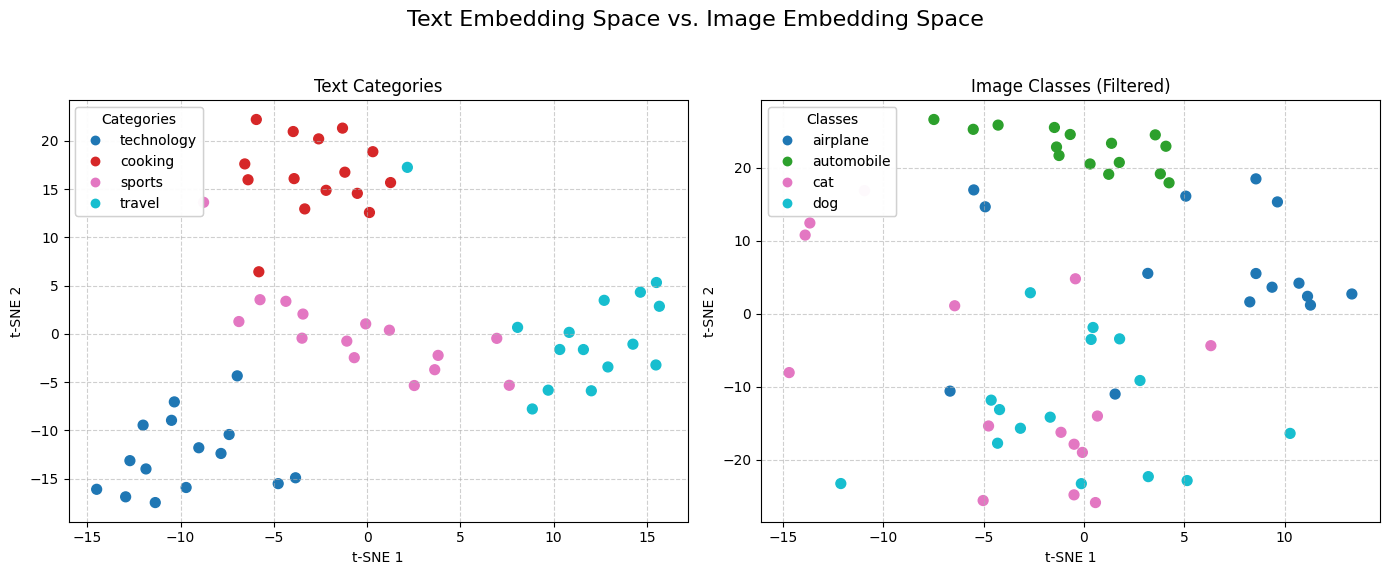

In [11]:
print("Applying t-SNE to text embeddings...")
# Use perplexity=10 for the smaller text dataset (60 items)
tsne_text = TSNE(n_components=2, random_state=42, perplexity=10)
text_2d = tsne_text.fit_transform(text_embeddings)
print(f"Shape of text_2d: {text_2d.shape}")

print("Applying t-SNE to image embeddings...")
# Use perplexity=15 for the larger image dataset (150 items)
tsne_image = TSNE(n_components=2, random_state=42, perplexity=15)
image_2d = tsne_image.fit_transform(image_embeddings)
print(f"Shape of image_2d: {image_2d.shape}")

# --- Plotting --- #
fig, (ax_text, ax_img) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Text Embedding Space vs. Image Embedding Space", fontsize=16)

# Left subplot: Text t-SNE
# Generate unique numerical labels for text categories for consistent coloring
unique_text_categories = list(set(text_categories))
text_category_to_id = {cat: i for i, cat in enumerate(unique_text_categories)}
text_numerical_labels = [text_category_to_id[cat] for cat in text_categories]

scatter_text = ax_text.scatter(text_2d[:, 0], text_2d[:, 1], c=text_numerical_labels, cmap='tab10', s=50)
ax_text.set_xlabel('t-SNE 1')
ax_text.set_ylabel('t-SNE 2')
ax_text.set_title('Text Categories')
# Create legend for text categories
legend1 = ax_text.legend(handles=scatter_text.legend_elements()[0], labels=unique_text_categories, title="Categories", loc='upper left')
ax_text.add_artist(legend1)
ax_text.grid(True, linestyle='--', alpha=0.6)

# Right subplot: Image t-SNE
# Filter images to only include the 4 classes used as query examples in Cell 7
# These are 'airplane':0, 'automobile':1, 'cat':3, 'dog':5
selected_image_labels_for_tsne = selected_cifar_indices # Use the predefined variable

# Create a boolean mask to select only these classes
mask = np.isin(img_labels, selected_image_labels_for_tsne)

# Apply the mask to both the 2D t-SNE points and the original labels
filtered_image_2d = image_2d[mask]
filtered_img_labels = np.array(img_labels)[mask] # Convert img_labels to numpy array for boolean indexing

scatter_img = ax_img.scatter(filtered_image_2d[:, 0], filtered_image_2d[:, 1], c=filtered_img_labels, cmap='tab10', s=50)
ax_img.set_xlabel('t-SNE 1')
ax_img.set_ylabel('t-SNE 2')
ax_img.set_title('Image Classes (Filtered)') # Update title to reflect filtering
# Create legend for image classes
# Map numerical labels back to their names, only for the selected classes
handles, _ = scatter_img.legend_elements()
legend_labels = [img_names[i] for i in sorted(list(set(filtered_img_labels)))]
legend2 = ax_img.legend(handles=handles, labels=legend_labels, title="Classes", loc='upper left')
ax_img.add_artist(legend2)
ax_img.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Look at both plots.  
  
How many distinct clusters can you count in each?  
Text has 4 distinct clusters, maybe 5 if we separate sports into 2 clusters.
Images have 3 clusters, but only 2 are distinct. Airplanes and Automobiles. Cats and Dogs are not very distinct and there are some airplanes scattered everywhere. Automobiles have a very clear distinction.
  
Are the text categories more cleanly separated than the image classes, or the other way around?  
The text categories are far more cleanly separated than the images.
  
What does this tell you about the relative difficulty of text categorization vs. image classification for these particular datasets?
Text requires fewer dimensions in order to be clearly distinguished. Images are very complex and are not easy to classify, even with significantly more dimensions considered in analysis.

## Cell 10: Failure Comparison


--- Text Failure ---
Query: Skiing down snowy mountains is an exhilarating winter sport.... (sports)
Matched: Taking a scenic train ride through the Swiss Alps.... (travel)
Score: 0.488

--- Image Failure ---


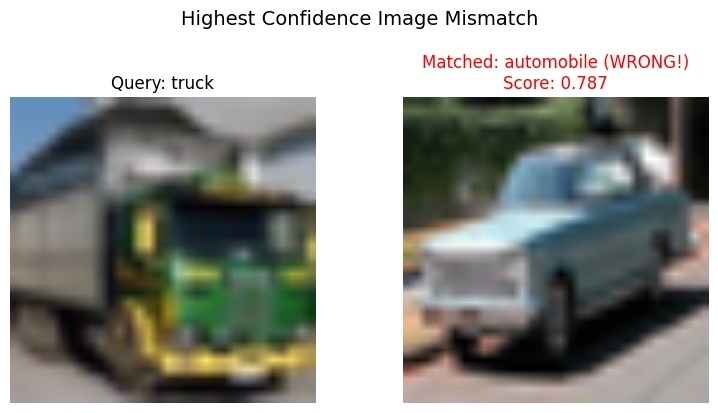

In [14]:
import matplotlib.pyplot as plt

# --- Text Failure Search ---
max_text_score = -1
text_failure_details = None

for i in range(len(texts)):
    query_category = text_categories[i]

    # find_similar_text returns query_idx, query_category, results
    # We only need the results for this loop, so we unpack the first two with underscores
    _, _, results = find_similar_text(i, n=1)

    # The results is a list of dictionaries; for n=1, we take the first item.
    match_idx = results[0]['index']
    score = results[0]['score']
    match_category = text_categories[match_idx]

    if query_category != match_category and score > max_text_score:
        max_text_score = score
        text_failure_details = {
            'query_idx': i,
            'match_idx': match_idx,
            'score': score,
            'query_text': texts[i],
            'match_text': texts[match_idx],
            'query_cat': query_category,
            'match_cat': match_category
        }

# --- Print Text Failure ---
if text_failure_details:
    print("\n--- Text Failure ---")
    print(f"Query: {text_failure_details['query_text'][:80]}... "
          f"({text_failure_details['query_cat']})")
    print(f"Matched: {text_failure_details['match_text'][:80]}... "
          f"({text_failure_details['match_cat']})")
    print(f"Score: {text_failure_details['score']:.3f}")
else:
    print("No text failures found with confident wrong matches.")

# --- Image Failure Search ---
max_image_score = -1
image_failure_details = None

for i in range(len(images)):
    query_label_id = img_labels[i]
    # find_similar_image correctly returns two values
    top_n_indices, top_n_scores = find_similar_image(i, n=1)

    match_idx = top_n_indices[0]
    score = top_n_scores[0]
    match_label_id = img_labels[match_idx]

    if query_label_id != match_label_id and score > max_image_score:
        max_image_score = score
        image_failure_details = {
            'query_idx': i,
            'match_idx': match_idx,
            'score': score,
            'query_label': img_names[query_label_id],
            'match_label': img_names[match_label_id]
        }

# --- Display Image Failure ---
if image_failure_details:
    print("\n--- Image Failure ---")
    query_img_idx = image_failure_details['query_idx']
    match_img_idx = image_failure_details['match_idx']
    query_img_label = image_failure_details['query_label']
    match_img_label = image_failure_details['match_label']
    score = image_failure_details['score']

    fig, axes = plt.subplots(1, 2, figsize=(8, 4)) # Reduced figure size

    # Query Image
    axes[0].imshow(resized_images[query_img_idx].numpy().astype('uint8'))
    axes[0].set_title(f"Query: {query_img_label}")
    axes[0].axis('off')

    # Wrong Match Image
    axes[1].imshow(resized_images[match_img_idx].numpy().astype('uint8'))
    axes[1].set_title(f"Matched: {match_img_label} (WRONG!)\nScore: {score:.3f}", color='red')
    axes[1].axis('off')

    plt.suptitle('Highest Confidence Image Mismatch', y=1.02, fontsize=14)
    plt.tight_layout()
    plt.show()
    plt.close(fig) # Explicitly close the figure
else:
    print("No image failures found with confident wrong matches.")

What kind of confusion did the text model produce?  
The text model confused a sentence about 'Skiing down snowy mountains' (sports category) with one about 'Taking a scenic train ride through the Swiss Alps' (travel category). This confusion arises because both activities share an abstract theme: winter leisure activities in mountainous regions, which are common contexts for both sports and travel.  
  
What kind did the image model produce?  
The image model confused a 'truck' (query) with an 'automobile' (match). This failure is based on shared visual characteristics, as both are vehicles with similar structural components, wheels, and often appear in similar environments.
  
Text models tend to confuse topics that share abstract themes. Image models tend to confuse objects that share visual structure. Describe one specific difference between the two failure modes. How does this reflect the fundamental difference between reading text and seeing images?  
This difference reflects that reading text often involves extracting meaning from abstract, semantic relationships and contextual understanding, leading to confusions when themes overlap. Seeing images, on the other hand, relies heavily on processing raw visual data, patterns, shapes, and textures, which results in confusions when objects share strong perceptual similarities, regardless of their precise semantic category.